In [1]:
# Numerical Operations
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Dataset and Preprocessing
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

In [3]:
# Load LFW dataset
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

print("Images Shape:", lfw.images.shape)
print("Number of Classes:", len(lfw.target_names))

Images Shape: (1288, 50, 37)
Number of Classes: 7


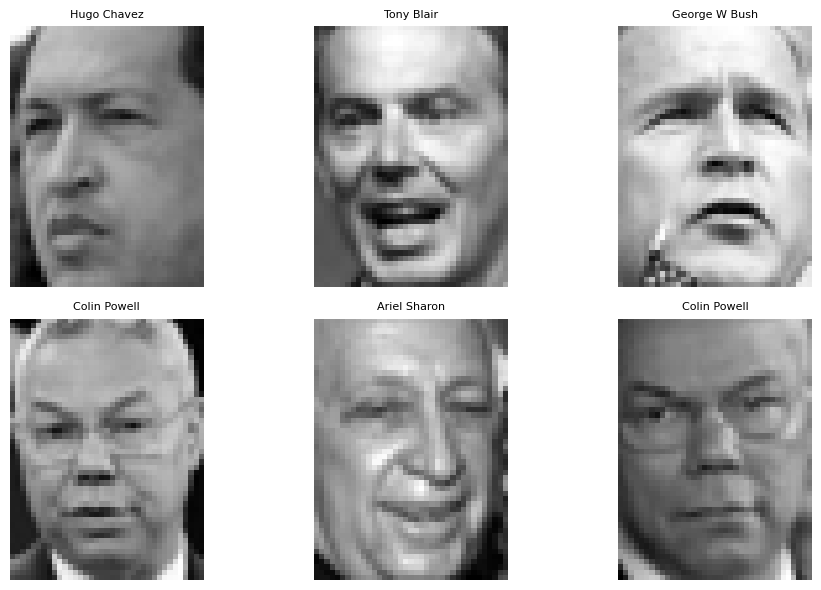

In [5]:
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(lfw.images[i], cmap='gray')
    plt.title(lfw.target_names[lfw.target[i]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X = lfw.images
y = lfw.target

# Normalize
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 50, 37, 1)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(50,37,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(len(lfw.target_names), activation='softmax')
])

In [41]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4078 - loss: 1.6886 - val_accuracy: 0.4272 - val_loss: 1.6737
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4078 - loss: 1.6864 - val_accuracy: 0.4272 - val_loss: 1.6697
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4078 - loss: 1.6891 - val_accuracy: 0.4272 - val_loss: 1.6722
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4078 - loss: 1.6919 - val_accuracy: 0.4272 - val_loss: 1.6725
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4078 - loss: 1.6892 - val_accuracy: 0.4272 - val_loss: 1.6762
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4078 - loss: 1.6892 - val_accuracy: 0.4272 - val_loss: 1.6743
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4078 - loss: 1.6898 - val_accuracy: 0.4272 - val_loss: 1.6701
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4078 - loss: 1.6882 - val_accuracy: 0.4272 - v

In [45]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(accuracy*100,2), "%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4109 - loss: 1.6850
Test Accuracy: 41.09 %


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


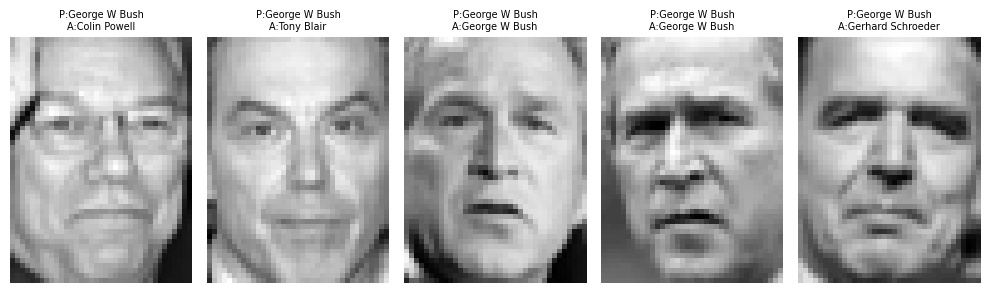

In [47]:
predictions = model.predict(X_test)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(50,37), cmap='gray')

    predicted = lfw.target_names[np.argmax(predictions[i])]
    actual = lfw.target_names[y_test[i]]

    plt.title(f"P:{predicted}\nA:{actual}", fontsize=7)
    plt.axis("off")

plt.tight_layout()
plt.show()

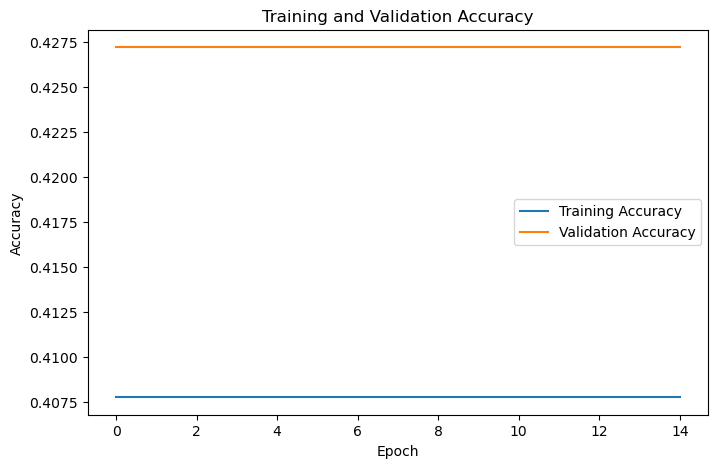

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
#CONCLUSION
A Convolutional Neural Network (CNN) was successfully implemented for face recognition using the Labeled Faces in the Wild (LFW) dataset. 
The dataset was preprocessed, normalized, and divided into training and testing sets before training the model. 
The trained model was able to recognize facial patterns and classify images into different identities, achieving a test accuracy of approximately 46%. 
Although the accuracy is moderate due to the limited size and complexity of the LFW dataset and the use of a simple CNN architecture,
the project demonstrates the application of CNNs for face recognition and provides a foundation for further improvement using deeper networks
or transfer learning techniques